In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np


#Getting data ready (turning images into tensors)

In [6]:
import pandas as pd
labels_csv = pd.read_csv("/Users/lukeopany/Desktop/dog-vision/labels.csv")
labels_csv.head()

,id,breed
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo
2,001cdf01b096e06d78e9e5112d419397,pekinese
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever


<Axes: xlabel='breed'>

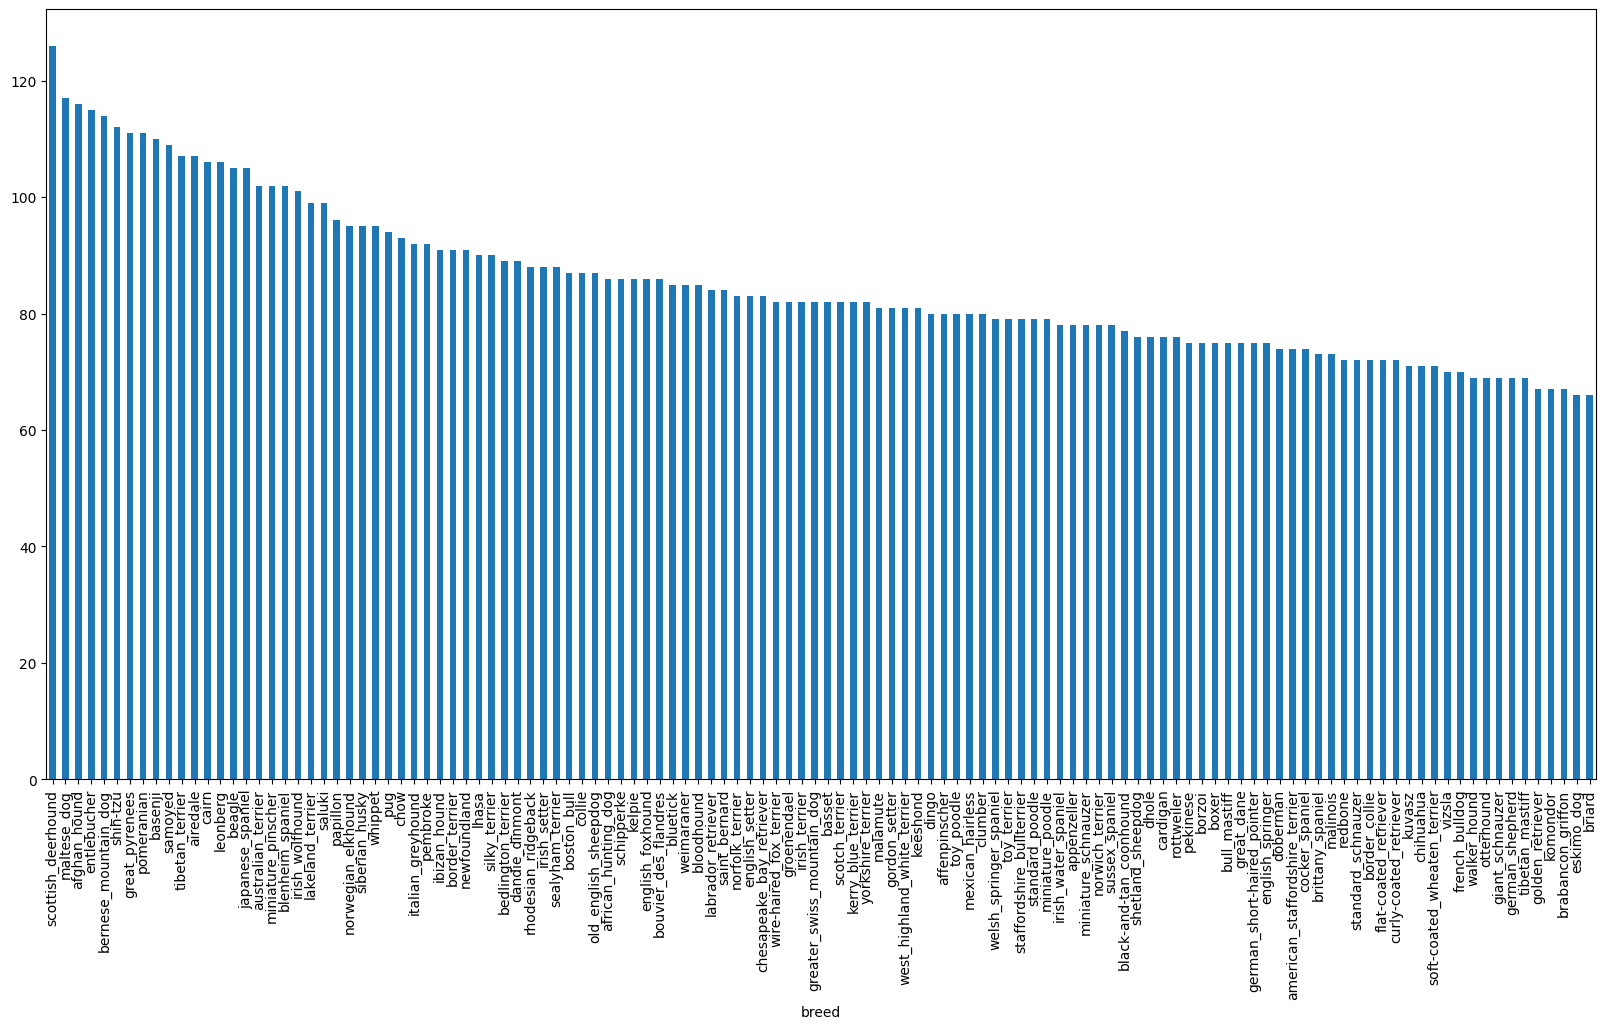

In [7]:
#Find out how many dog breeds are there for each class and plot
labels_csv["breed"].value_counts().plot.bar(figsize=(20,10))

In [8]:
print(labels_csv["breed"].value_counts().mean())

85.18333333333334


In [ ]:
#Viewing an image inside the notebook -- copy the image file path and include image id

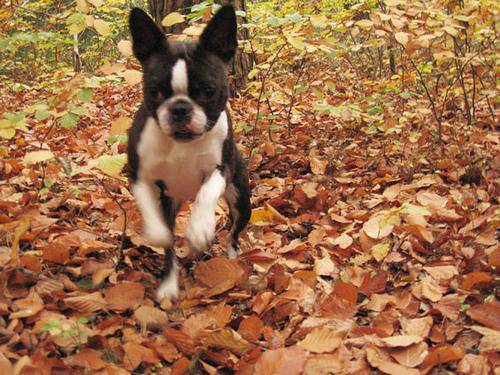

In [9]:
from IPython.display import Image
Image("/Users/lukeopany/Desktop/dog-vision/train/000bec180eb18c7604dcecc8fe0dba07.jpg")

Because it would take a lot of time to type out the filepath each time we need to get an image, we are going to create a pathname from image IDs

In [10]:
#Create pathname from image ID's
filename = "/Users/lukeopany/Desktop/dog-vision/train/" + labels_csv["id"] + ".jpg"
# Avoid printing the full Series (can freeze the notebook output)
filename.head()

0    /Users/lukeopany/Desktop/dog-vision/train/000b...
1    /Users/lukeopany/Desktop/dog-vision/train/0015...
2    /Users/lukeopany/Desktop/dog-vision/train/001c...
3    /Users/lukeopany/Desktop/dog-vision/train/0021...
4    /Users/lukeopany/Desktop/dog-vision/train/0021...
Name: id, dtype: str

In [ ]:
#Check whether the number of filenames matches the number of actual images

In [11]:
import os

# Get the list of all files in the training directory
train_path = "/Users/lukeopany/Desktop/dog-vision/train/"
files = os.listdir(train_path)

# Compare the lengths
print(f"Number of filenames generated: {len(filename)}")
print(f"Number of actual images in folder: {len(files)}")

if len(filename) == len(files):
    print("Success: The number of filenames matches the number of actual images.")
else:
    print("Warning: The number of filenames does not match the number of actual images.")

Number of filenames generated: 10222
Number of actual images in folder: 10222
Success: The number of filenames matches the number of actual images.


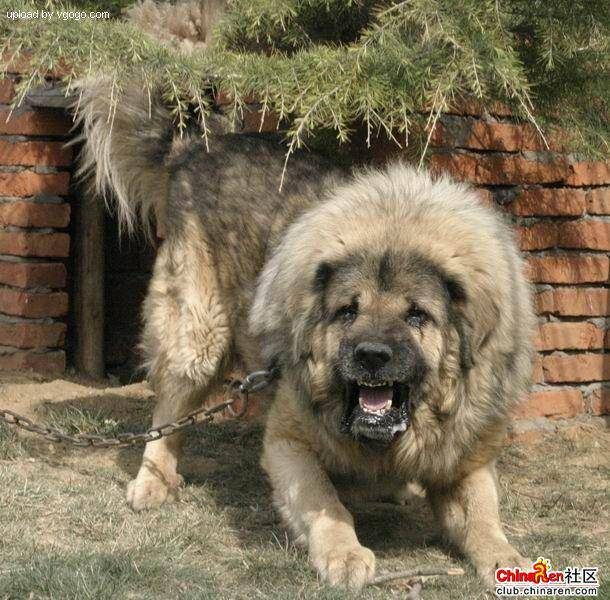

In [12]:
#One more check
from IPython.display import Image
Image(filename[9000])

In [13]:
labels_csv['breed'][9000]

'tibetan_mastiff'

Since we've now got our training image filepath in a list, let's prepare our lables

In [14]:
import numpy as np
labels = labels_csv['breed']
labels = np.array(labels)
len(labels)

10222

In [ ]:
#compare the number of labels to the number in files

In [15]:
# Compare the number of labels to the number of actual images in the folder
print(f"Number of labels: {len(labels)}")
print(f"Number of actual images in folder: {len(files)}")

if len(labels) == len(files):
    print("Success: The number of labels matches the number of actual images.")
else:
    print("Warning: There is a mismatch between the number of labels and image files.")

Number of labels: 10222
Number of actual images in folder: 10222
Success: The number of labels matches the number of actual images.


In [16]:
# Find the unique value labels
unique_breeds = np.unique(labels)
len(unique_breeds)

120

In [17]:
# Turn a single label into an array of booleans
labels[0] == unique_breeds

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False,  True, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False])

In [18]:
# Turn every label into an array of booleans
boolean_labels = [label == unique_breeds for label in labels]
boolean_labels[:2]

[array([False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False,  True, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False]),
 array([False, False, False, False, False, Fal

In [ ]:
len(boolean_labels)

10222

In [19]:
# Example: Turning a boolean array into integers
print(labels[0]) # Original labels
print(np.where(unique_breeds == labels[0])) #index where label occurs
print(boolean_labels[0].argmax()) # index where label occurs in boolean array
print(boolean_labels[0].astype(int)) # There will be a 1 where the sample occurs



boston_bull
(array([19]),)
19
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0]


In [ ]:
print(labels[2])
print(boolean_labels[2].astype(int))


pekinese
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0]


In [20]:
filename[:10]

0    /Users/lukeopany/Desktop/dog-vision/train/000b...
1    /Users/lukeopany/Desktop/dog-vision/train/0015...
2    /Users/lukeopany/Desktop/dog-vision/train/001c...
3    /Users/lukeopany/Desktop/dog-vision/train/0021...
4    /Users/lukeopany/Desktop/dog-vision/train/0021...
5    /Users/lukeopany/Desktop/dog-vision/train/0022...
6    /Users/lukeopany/Desktop/dog-vision/train/0029...
7    /Users/lukeopany/Desktop/dog-vision/train/002a...
8    /Users/lukeopany/Desktop/dog-vision/train/003d...
9    /Users/lukeopany/Desktop/dog-vision/train/0042...
Name: id, dtype: str

This whole process has been trying to get our data into an accesible format

Creating our own validation set

In [ ]:
#This can be achieved by creating the X and y variable (normally for test-train split but can be used in our case to split the data into train - val)

In [22]:
x = filename
y = boolean_labels

In [23]:
len(x), len(y)

(10222, 10222)

In [ ]:
#To save time, start with ~1000 samples 

In [24]:
# Set the number of images to use for experimenting
NUM_IMAGES = 1000
# Split into train and validation sets (80/20 split)
NUM_TRAIN = int(NUM_IMAGES * 0.8)  # 800 images for training -- int ensures no float(decimals)

x_train = x[:NUM_TRAIN]
y_train = y[:NUM_TRAIN]

x_val = x[NUM_TRAIN:NUM_IMAGES]
y_val = y[NUM_TRAIN:NUM_IMAGES]

print(f"Training samples:   {len(x_train)}")
print(f"Validation samples: {len(x_val)}")

Training samples:   800
Validation samples: 200
